In [25]:
import time
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
import idx2numpy # pip install idx2numpy
import gzip
import shutil
from pathlib import Path
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,Flatten # import my implmentation
from sklearn.datasets import load_digits

In [26]:
digits = load_digits()
digits.images.shape

(1797, 8, 8)

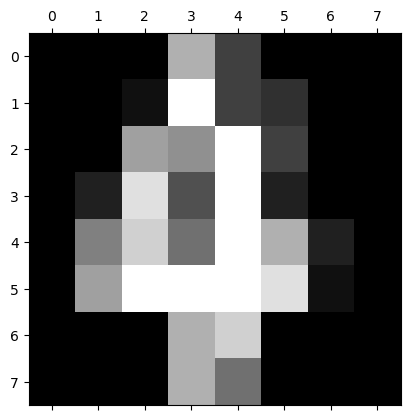

In [27]:
plt.matshow(digits.images[400], cmap="gray")

In [28]:
X=digits.images
y=digits.target
#digits.target_names  


In [29]:
SEED = 24
(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)
X_train=X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2]) # adding channel dimension

In [30]:
# normalization
X_max = np.max(X_train)
X_train = (X_train) / (X_max)
X_test = (X_test ) / (X_max)


In [31]:
y_train_one_hot=to_one_hot(y_train,10)
y_test_one_hot=to_one_hot(y_test,10)

In [32]:
X_train.shape

(1618, 1, 8, 8)

In [75]:
subgroup=1618
sub_X_train = X_train[0:subgroup] 
sub_y_train = y_train_one_hot[0:subgroup]

In [76]:
importlib.reload(deep_learning.model)
importlib.reload(deep_learning.utils)
from deep_learning.model import SequentialNetwork,Dense,Softmax,CrossEntropy,ReLU,Convolution2D,AVGPooling,Flatten # import my implmentation
EPOCHS = 10
LR = 0.2

# Lenet-5
model = SequentialNetwork(layers=[
    Convolution2D(kernel_size=(5,5),n_kernels=2, input_shape=(1,8,8), stride=1, padding=2, activation_function=ReLU(), lr=LR, seed=SEED),
    AVGPooling(kernel_size=(2,2)), #Output (2,4,4)
    Flatten(),
    Dense(inputs=32, neurons=100, activation_function=ReLU(), lr=LR, seed=SEED),
   # Dense(inputs=200, neurons=50, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=100, neurons=10, activation_function=Softmax(), lr=LR, seed=SEED)
], loss_function=CrossEntropy())
# see parameters update
# neurons and  connections in second convolution
#make net scheme
#revisar sin el backward queda bien las dimensiones cuando hay padding

Convolutional 2D layer with: 52 trainable parameters, 128 neurons, 3328 connections, Input: (1, 8, 8),  Output: (2, 8, 8)
AVGPooling layer with kernel size: 2 x 2
Flatten layer
Dense layer with: 6600 trainable parameters, 200 neurons, 6600 connections
Dense layer with: 10050 trainable parameters, 50 neurons, 10050 connections
Dense layer with: 510 trainable parameters, 10 neurons, 510 connections


In [ ]:

start = time.perf_counter()
BATCH_SIZE=len(X_train)
for epoch in range(EPOCHS):
   epoch_loss = model._train_one_epoch(sub_X_train,sub_y_train, BATCH_SIZE)
   print(f"Epoch: {epoch+1} | Loss: {epoch_loss}")
loss=model.losses
end = time.perf_counter()
print(f"Elapsed time: {end - start} seconds")

Epoch: 1 | Loss: 2.3025850503715874
Epoch: 2 | Loss: 2.3025714467166356
Epoch: 3 | Loss: 2.3025583824175264
Epoch: 4 | Loss: 2.302545838436167
Epoch: 5 | Loss: 2.302533791927238


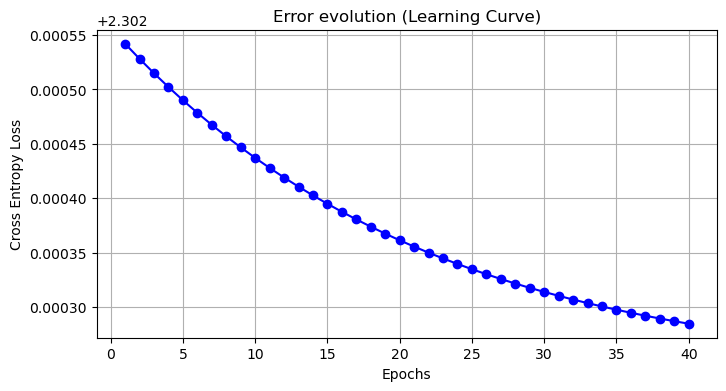

In [117]:
plot_learning_curve(loss, ylabel='Cross Entropy Loss')

In [118]:
probs = model.predict(X_test)      
preds=np.argmax(probs,axis=1)

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (4,2)  and requested shape (3,2)

In [15]:
#for  pred, yi in zip( preds, test_labels):
#    print(f"true: {int(yi)}  prediction: {pred} ")

accuracy = np.mean(preds == test_labels)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 98.31%
